Loading data from ../data/raw/training.csv...
Total missing detector values found: 1580052
Data cleaning complete. Shape of X: (250000, 30), Shape of y: (250000,)


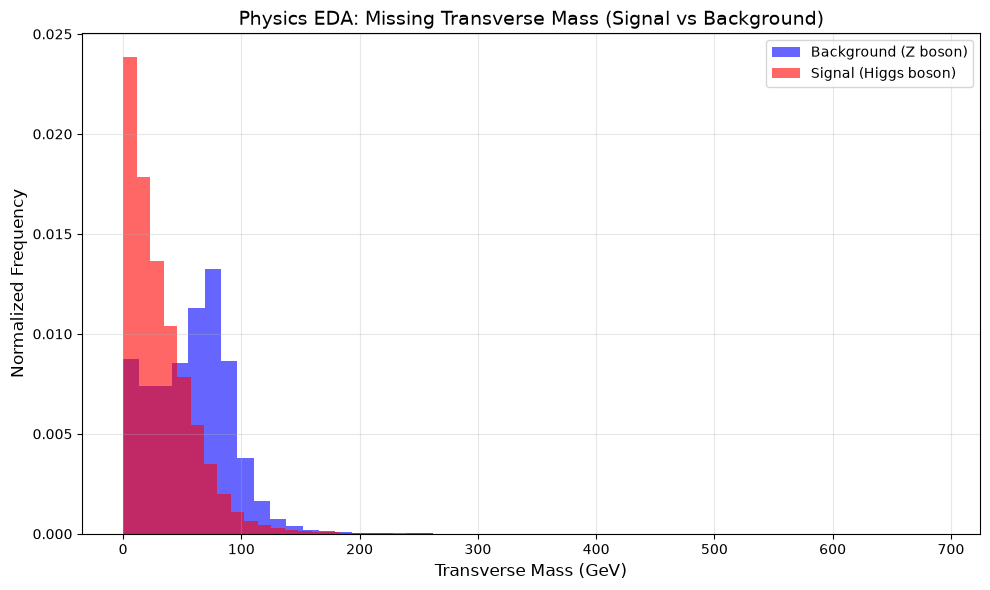

EDA Complete. Look at the plot: Does the Signal peak at a higher mass than the Background?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the path so we can import our custom module
sys.path.append(os.path.abspath('../src'))
from data_processing import load_and_clean_data

# 1. Load the data
X, y = load_and_clean_data('../data/raw/training.csv')

# 2. Separate Signal and Background for plotting
X_signal = X[y == 1]
X_background = X[y == 0]

# 3. Plot the Missing Transverse Energy (A key physics variable)
# Note: The exact column name in the Kaggle dataset is 'DER_mass_transverse_met_lept'
feature_to_plot = 'DER_mass_transverse_met_lep'

plt.figure(figsize=(10, 6))

# Plot Background (Z boson)
plt.hist(X_background[feature_to_plot], bins=50, alpha=0.6, color='blue', 
         label='Background (Z boson)', density=True)

# Plot Signal (Higgs boson)
plt.hist(X_signal[feature_to_plot], bins=50, alpha=0.6, color='red', 
         label='Signal (Higgs boson)', density=True)

plt.title('Physics EDA: Missing Transverse Mass (Signal vs Background)', fontsize=14)
plt.xlabel('Transverse Mass (GeV)', fontsize=12)
plt.ylabel('Normalized Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("EDA Complete. Look at the plot: Does the Signal peak at a higher mass than the Background?")

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from data_processing import load_and_clean_data

def train_higgs_model(file_path):
    """
    Loads data, splits it, and trains a Random Forest Classifier.
    """
    # 1. Load and Clean Data (using the function we wrote earlier)
    X, y = load_and_clean_data(file_path)
    
    # 2. Train-Test Split
    # We hold back 20% of the data to test the model later. 
    # This prevents "overfitting" (memorizing the data instead of learning physics).
    # random_state=42 ensures we get the exact same split every time we run it.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Note: stratify=y ensures the ratio of Signal/Background is the same in both train and test sets.
    
    print(f"Training set size: {X_train.shape[0]} events")
    print(f"Testing set size: {X_test.shape[0]} events")
    
    # 3. Initialize the Random Forest Model
    # n_estimators=100: We build 100 decision trees and average their votes.
    # max_depth=5: We limit how deep the trees can grow to prevent overfitting.
    # n_jobs=-1: Use all CPU cores on your laptop to train faster!
    model = RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        random_state=42, 
        n_jobs=-1
    )
    
    # 4. Train the Model
    print("\nTraining Random Forest... (This might take a minute)")
    model.fit(X_train, y_train)
    
    # 5. Quick Accuracy Check
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    
    return model, X_test, y_test

if __name__ == "__main__":
    # Test the function
    model, X_test, y_test = train_higgs_model('../data/raw/training.csv')

Loading data from ../data/raw/training.csv...
Total missing detector values found: 1580052
Data cleaning complete. Shape of X: (250000, 30), Shape of y: (250000,)
Training set size: 200000 events
Testing set size: 50000 events

Training Random Forest... (This might take a minute)
Training Accuracy: 0.8168
Testing Accuracy: 0.8136


In [4]:
import sys
import os

# 1. Tell Python to look inside the src folder
sys.path.append(os.path.abspath('../src'))

# 2. Import the function directly (DO NOT type 'src.' here!)
from model_training import train_higgs_model

# 3. Run the function
higgs_model, X_test, y_test = train_higgs_model('../data/raw/training.csv')

print("\n✅ Model training complete! Ready for evaluation.")

Loading data from ../data/raw/training.csv...
Total missing detector values found: 1580052
Data cleaning complete. Shape of X: (250000, 30), Shape of y: (250000,)
Training set size: 200000 events
Testing set size: 50000 events

Training Random Forest... (This might take a minute)
Training Accuracy: 0.8168
Testing Accuracy: 0.8136

✅ Model training complete! Ready for evaluation.


🎯 Model AUC Score: 0.8744
✅ ROC Curve saved to 'outputs/figures/roc_curve.png'


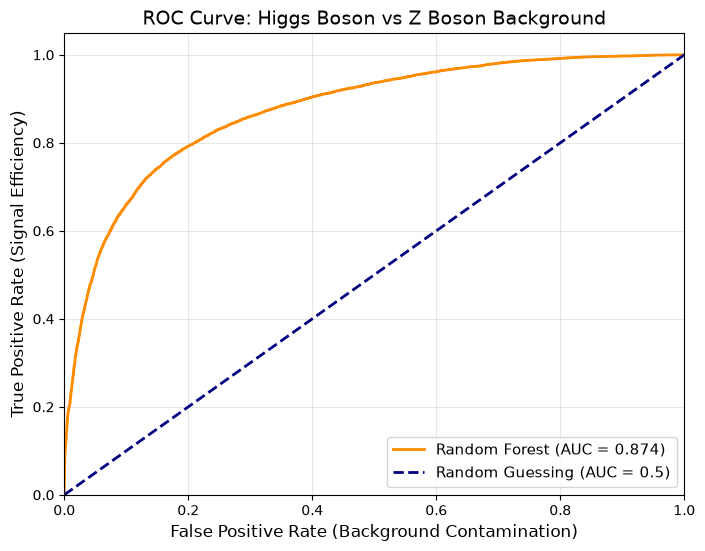

In [5]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

# Import the new evaluation function
from evaluation import evaluate_and_plot

# Pass the trained model and test data to the function
evaluate_and_plot(higgs_model, X_test, y_test)

Loading and cleaning data...
Loading data from ../data/raw/training.csv...
Total missing detector values found: 1580052
Data cleaning complete. Shape of X: (250000, 30), Shape of y: (250000,)

Running 5-Fold Cross-Validation... (This may take a minute)
Fold Scores: [0.90466001 0.90602839 0.90582217 0.90737804 0.90512045]
Mean CV AUC: 0.9058 (+/- 0.0019)

Training final model on full dataset...
✅ Feature Importance plot saved.


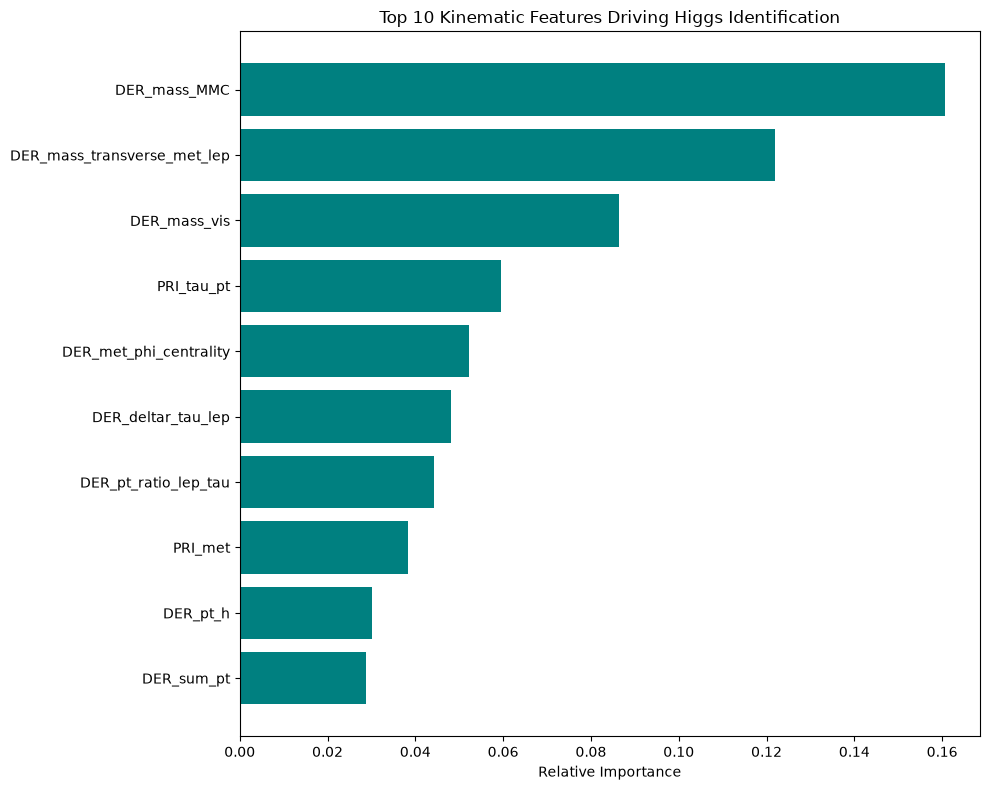

✅ Peak Physics Significance: 282.88
✅ Significance Curve saved.


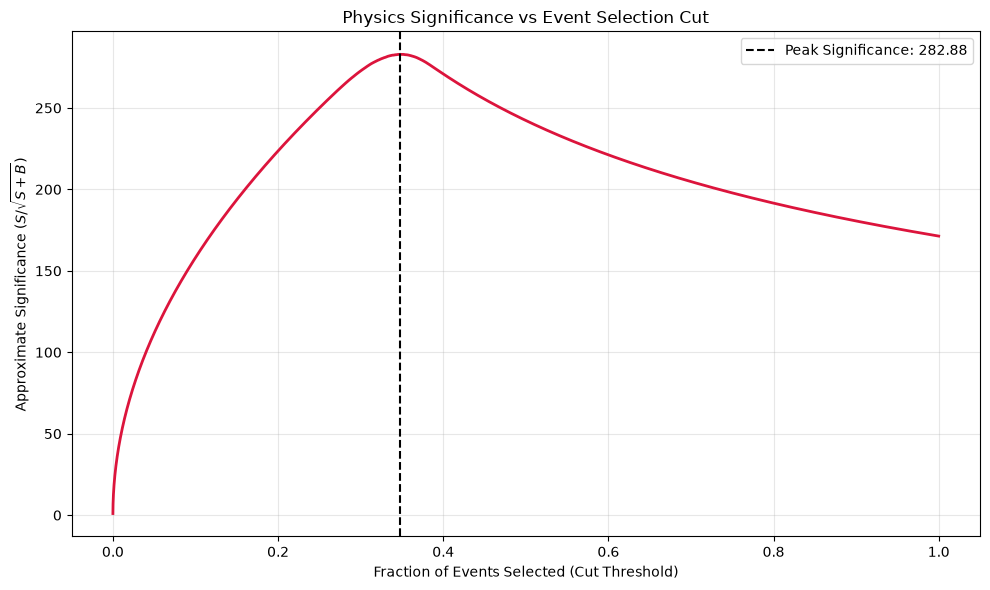

In [2]:
import sys
import os

# 1. Tell Python to look inside the src folder
sys.path.append(os.path.abspath('../src'))

# 2. Import the functions directly (DO NOT type 'src.' here!)
from model_training import train_higgs_model_advanced
from evaluation import advanced_evaluation

# 3. Run the upgraded pipeline
final_model, X_full, y_full = train_higgs_model_advanced('../data/raw/training.csv')
advanced_evaluation(final_model, X_full, y_full)

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 1.9 MB/s eta 0:00:55
   ---------------------------------------- 0.8/101.7 MB 1.9 MB/s eta 0:00:55
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:25
    --------------------------------------- 1.6/101.7 MB 1.5 MB/s eta 0:01:09
    --------------------------------------- 1.8/101.7 MB 1.4 MB/s eta 0:01:11
    --------------------------------------- 2.1/101.7 MB 1.5 MB/s eta 0:01:08
   - -------------------------------------- 2.6/101.7 MB 1.6 MB/s eta 0:01:04
   - -------------------------------------- 2.9/101.7 MB 1.6 MB/s eta 0:01:04
   - -------------------------------------- 3.4/101.7 MB 1.6 MB/s eta 0:01:01
   - -------------------------------------- 3.9/101.7 MB 1.7 MB/s eta 0:00:58
   - -------------------------------------- 4.2/101.7 MB 1.7 MB/s eta 0:00:57


In [ ]:
from sklearn.ensemble import RandomFocls
restClassifier

In [5]:
from xgboost import XGBClassifier

# Inside your training function...
rf_model = RandomForestClassifier(...)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1)

# Train both and compare their AUC scores

In [8]:
rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",Ellipsis
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `m

Training model (this will show the 5-fold CV results)...
Loading and cleaning data...
Loading data from ../data/raw/training.csv...
Total missing detector values found: 1580052
Data cleaning complete. Shape of X: (250000, 30), Shape of y: (250000,)

Running 5-Fold Cross-Validation... (This may take a minute)
Fold Scores: [0.90466001 0.90602839 0.90582217 0.90737804 0.90512045]
Mean CV AUC: 0.9058 (+/- 0.0019)

Training final model on full dataset...

Generating SHAP Explainable AI plots...
Calculating SHAP values (optimized for speed)...
Computing SHAP values for 200 events...
✅ SHAP Summary (Beeswarm) plot saved.


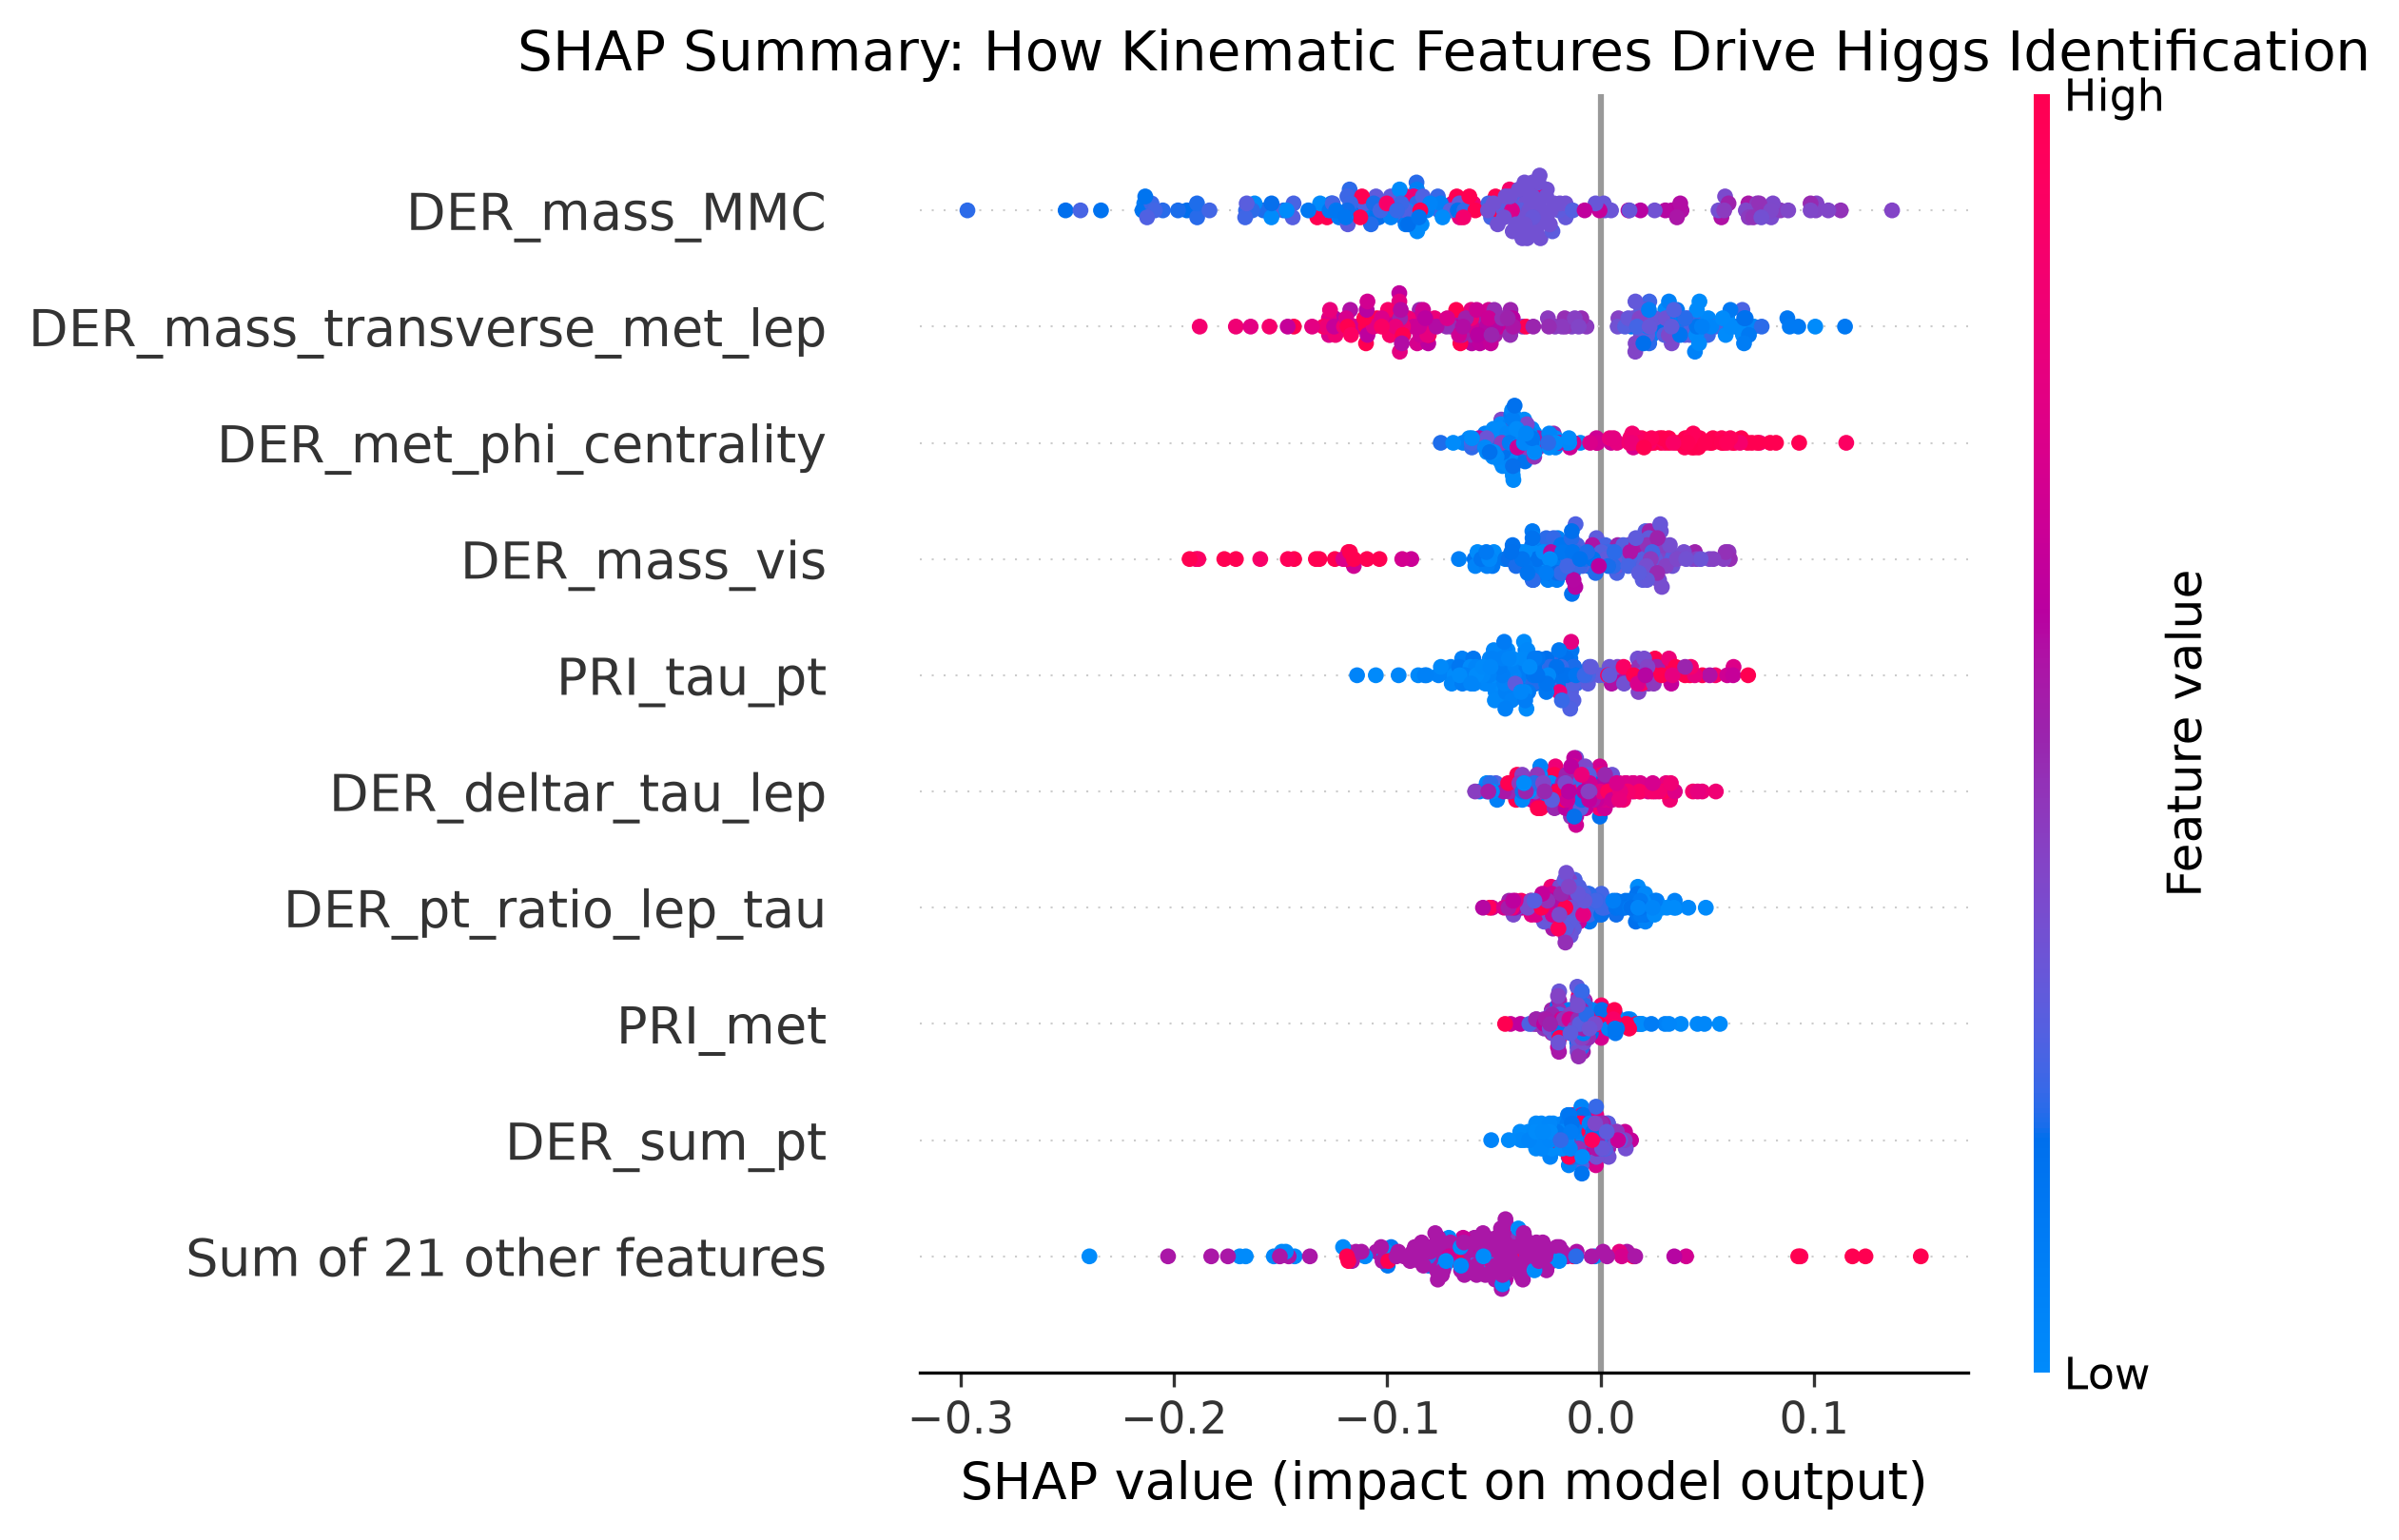

✅ SHAP Bar plot saved.


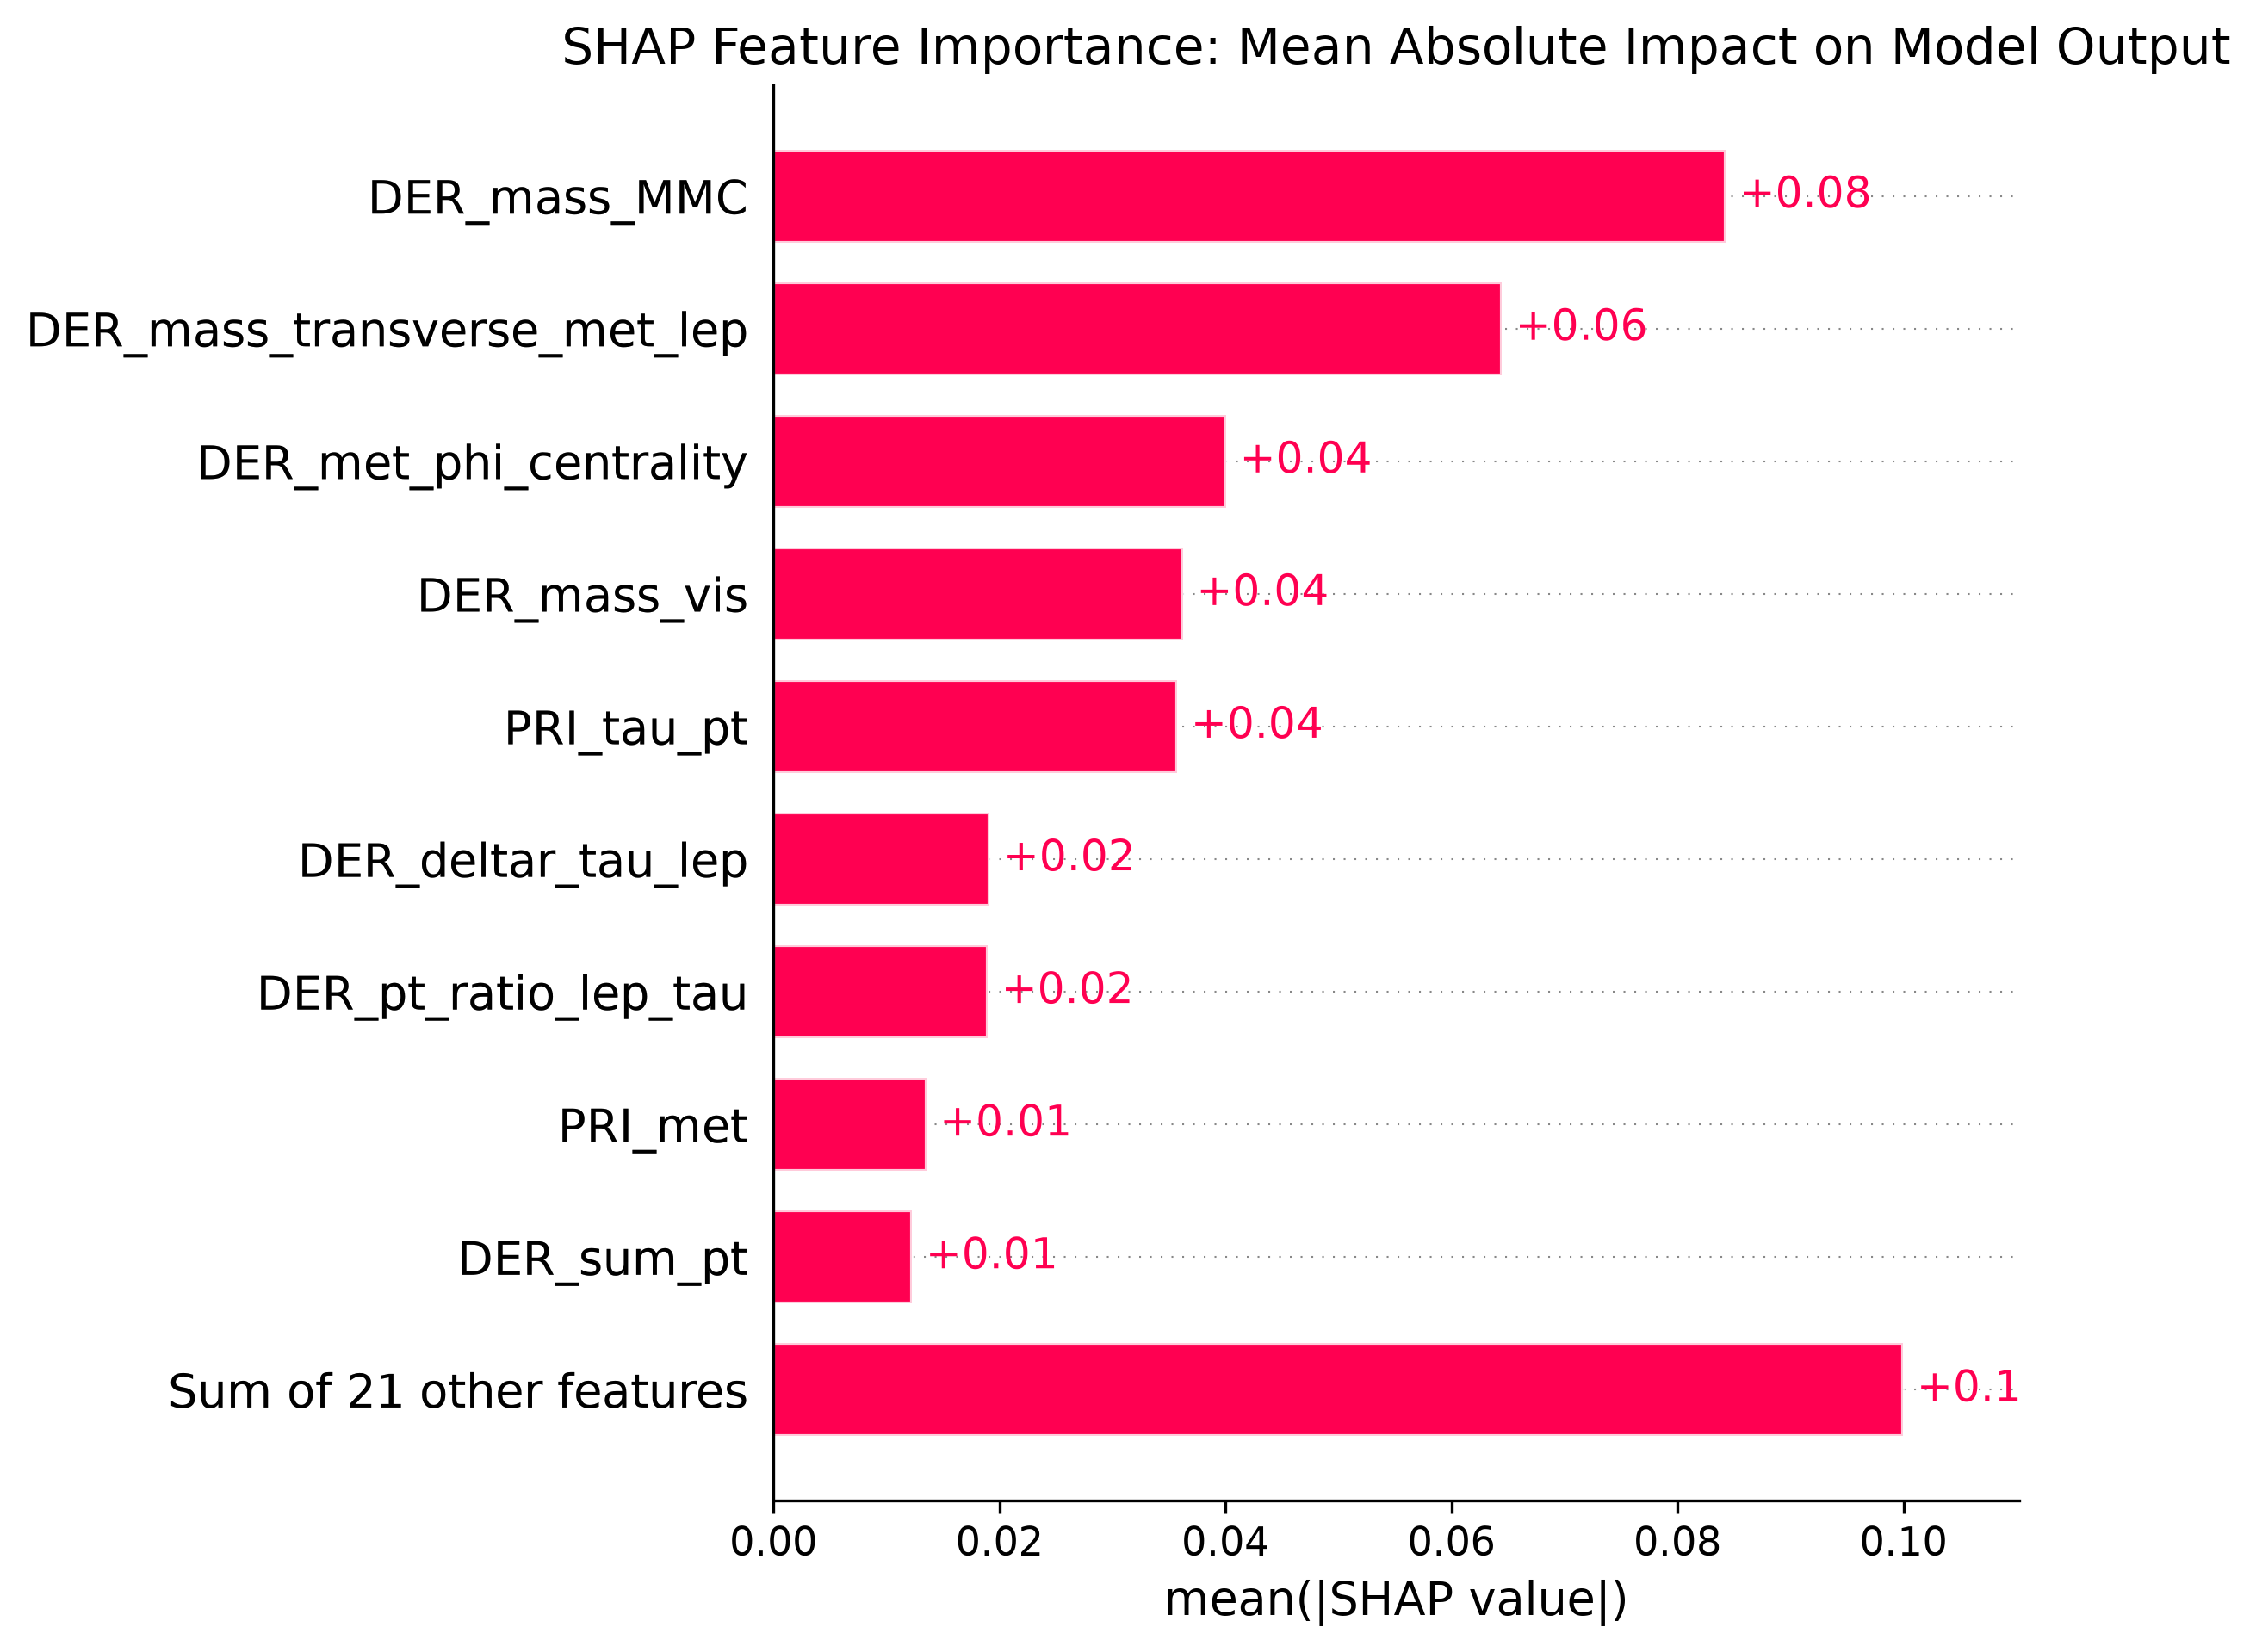

In [1]:
%matplotlib inline
import sys
import os
import pandas as pd

# 1. Add the src folder to the path
sys.path.append(os.path.abspath('../src'))

# 2. Import the functions
from model_training import train_higgs_model_advanced
from interpretability import generate_shap_analysis

# 3. Train the model and get the full dataset
print("Training model (this will show the 5-fold CV results)...")
final_model, X_full, y_full = train_higgs_model_advanced('../data/raw/training.csv')

# 4. Separate Signal and Background for SHAP analysis
X_background = X_full[y_full == 0]
X_signal = X_full[y_full == 1]

# 5. Generate the advanced SHAP plots
print("\nGenerating SHAP Explainable AI plots...")
generate_shap_analysis(final_model, X_background, X_signal, X_full.columns)

Loading data...
Loading data from ../data/raw/training.csv...
Total missing detector values found: 1580052
Data cleaning complete. Shape of X: (250000, 30), Shape of y: (250000,)

Generating PCA Visualization...
Performing PCA dimensionality reduction...
✅ PCA Complete. PC1 explains 22.6% and PC2 explains 10.2% of total variance.
   (Total variance captured in 2D: 32.8%)
✅ PCA Visualization plot saved.


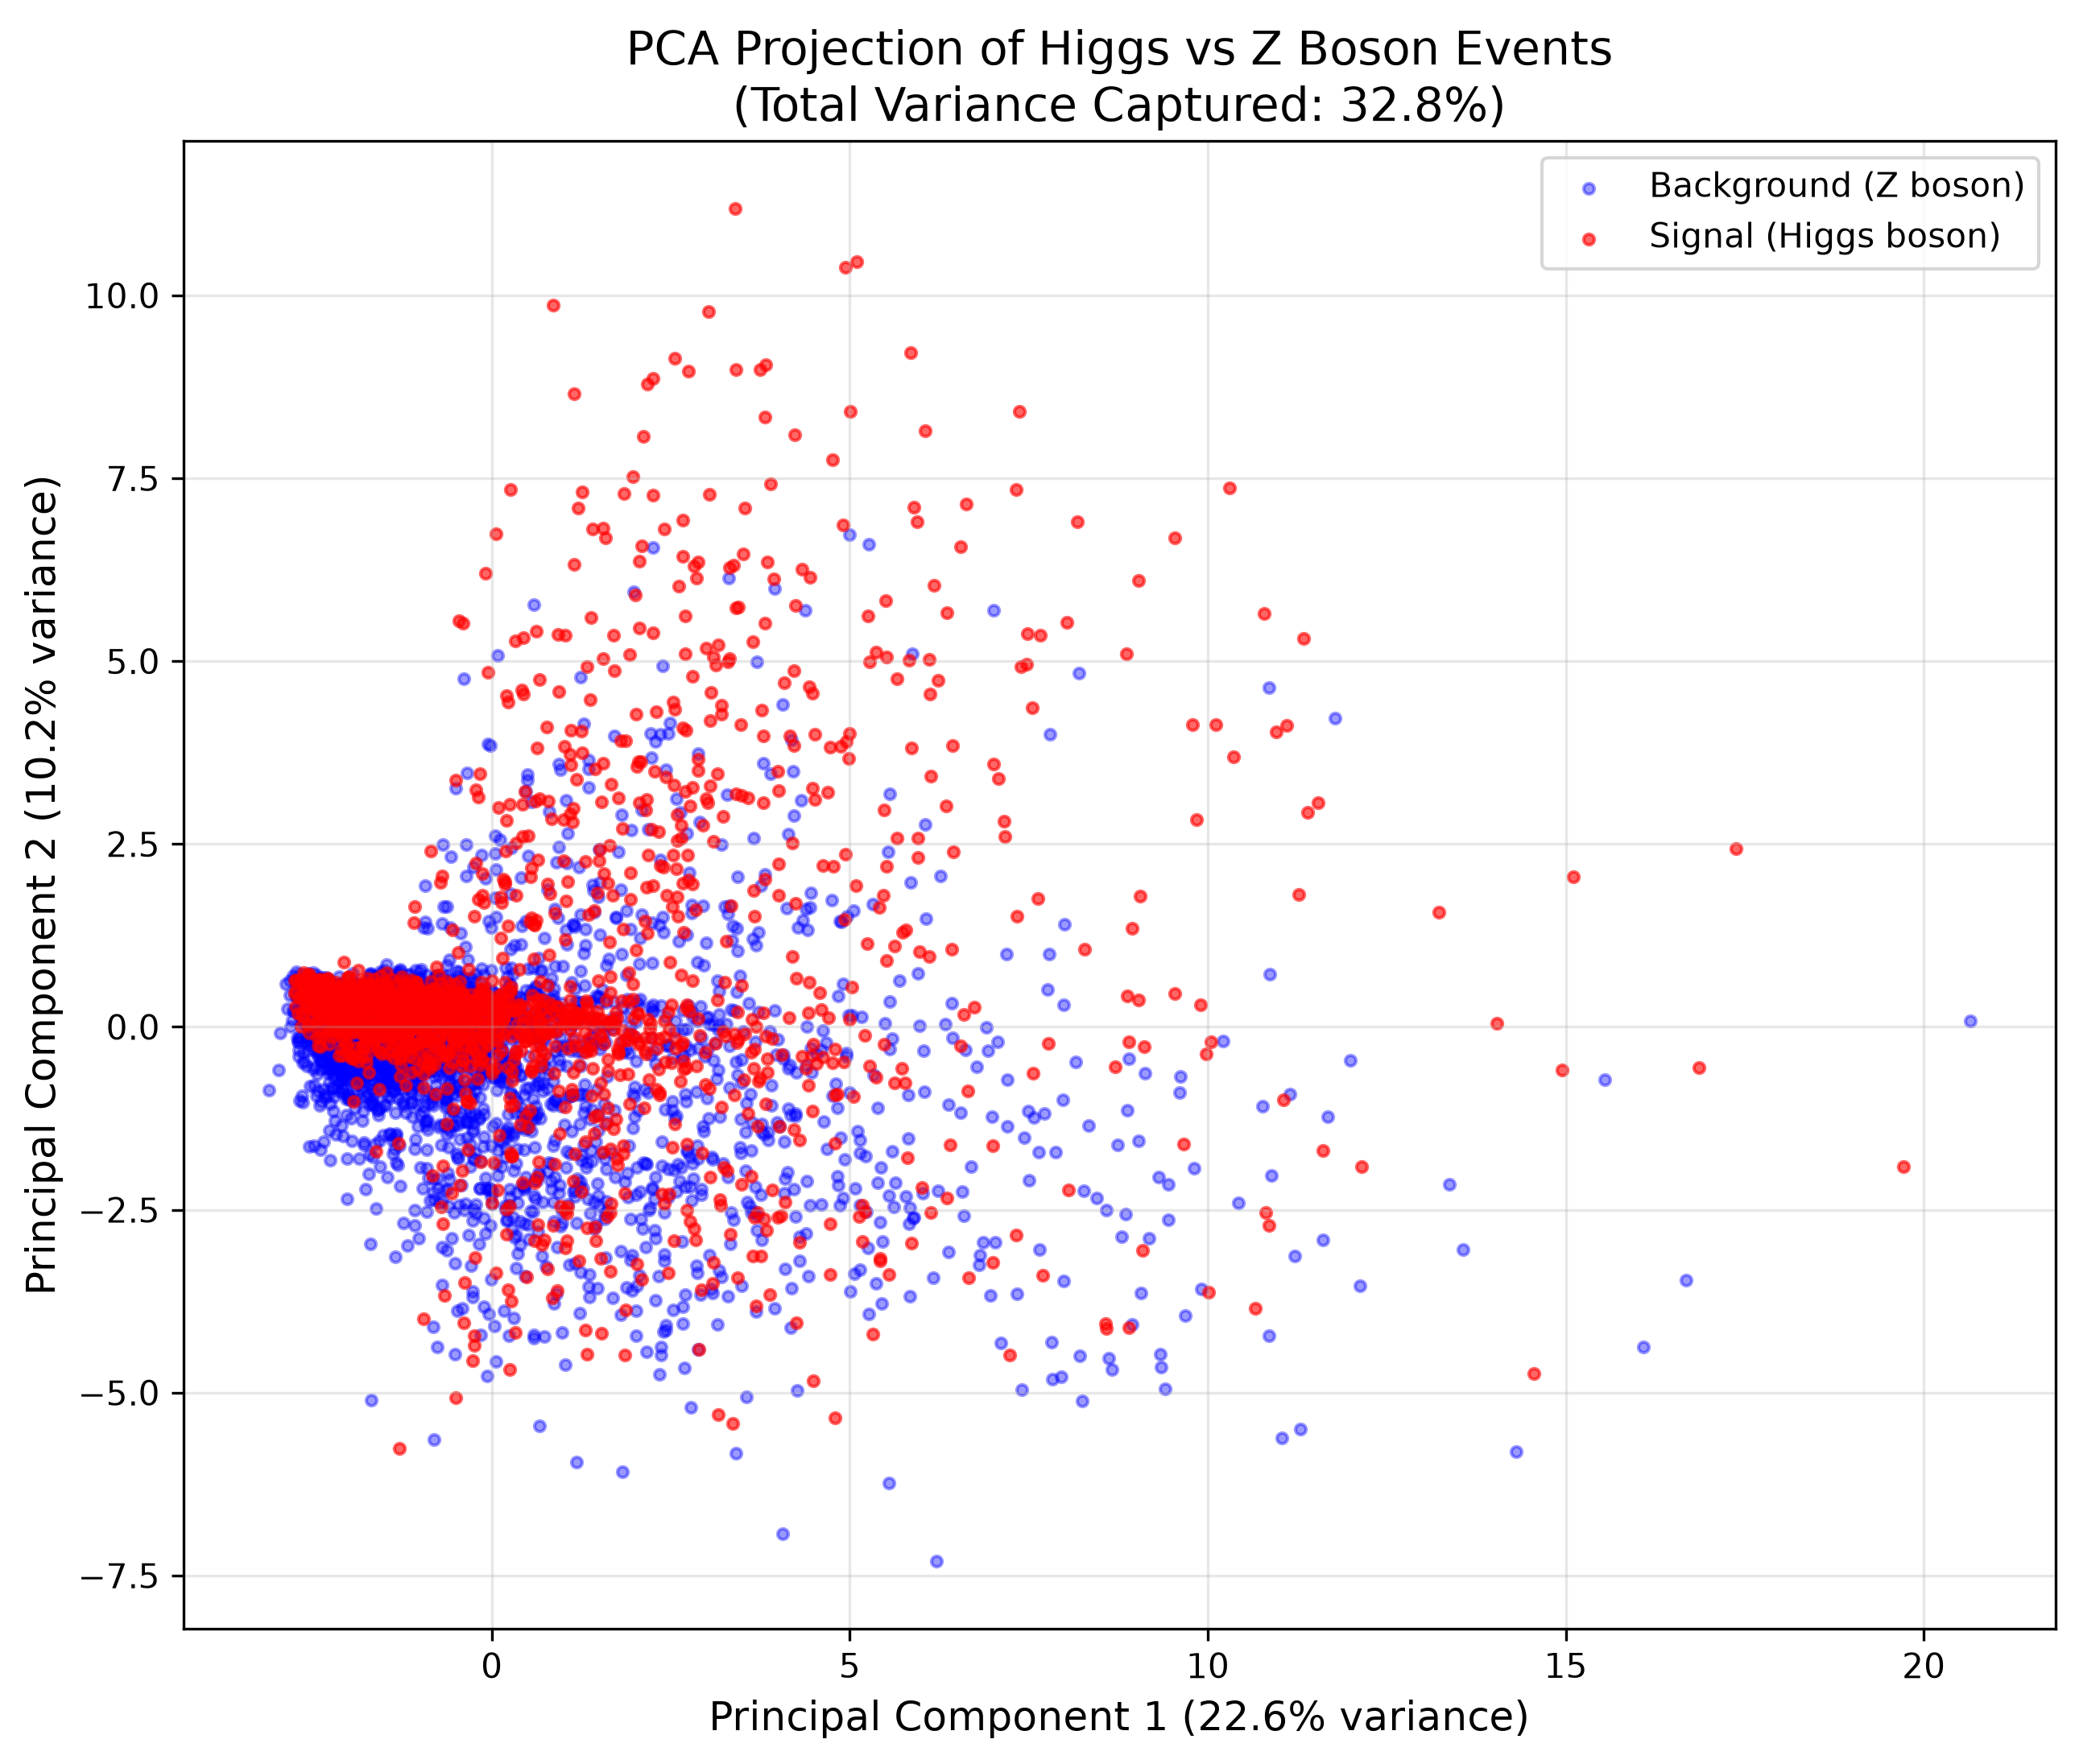

In [1]:
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.append(os.path.abspath('../src'))

# Import the new function
from interpretability import generate_pca_visualization
from data_processing import load_and_clean_data

# 1. Load the full cleaned dataset
print("Loading data...")
X_full, y_full = load_and_clean_data('../data/raw/training.csv')

# 2. Generate the PCA plot
print("\nGenerating PCA Visualization...")
generate_pca_visualization(X_full, y_full, X_full.columns)